In [25]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')
print("FutureWarnings from pandas are now suppressed.")

FutureWarnings from pandas are now suppressed.


## Phase 1: Audit & Import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load market_sales_data.csv
try:
    df = pd.read_csv('marketcorp_sales.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'marketcorp_sales.csv' not found. Please upload the file to your Colab environment.")
    df = None # Set df to None to avoid errors in subsequent operations

if df is not None:
    # Audit the file
    print("\n--- Dataset Shape ---")
    print(df.shape)

    print("\n--- Dataset Head (First 5 rows) ---")
    print(df.head())

    print("\n--- Dataset Description (Numerical columns) ---")
    print(df.describe())

    print("\n--- Dataset Information (Columns, Non-Null Counts, Dtypes) ---")
    print(df.info())

    print("\n--- Dataset Data Types ---")
    print(df.dtypes)

Dataset loaded successfully.

--- Dataset Shape ---
(2000, 12)

--- Dataset Head (First 5 rows) ---
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility    Item_Type  \
0           FDG61    17.281082              reg         0.191732  Snack Foods   
1           FDO81    11.664071          Regular         0.000000    Household   
2           FDU92    18.154878          Low Fat         0.051269        Dairy   
3           FDW84    18.605568          Regular         0.063893         Meat   
4           FDK97     8.391905          Low Fat         0.023267  Soft Drinks   

     Item_MRP Outlet_Identifier  Outlet_Establishment_Year Outlet_Size  \
0  206.660678            OUT012                       2004       Small   
1   77.860059            OUT036                       1999       Small   
2  118.363505            OUT016                       2004      Medium   
3  155.122827            OUT042                       2004      Medium   
4  170.986748            OUT018            

## Phase 2: Reliable Data

### Handling Missing Values and Data Standardization

In [26]:
# 1. Item_Weight: Replace NaN by mean
# Calculate the mean of 'Item_Weight'
mean_item_weight = df['Item_Weight'].mean()
# Fill missing values with the mean
df['Item_Weight'] = df['Item_Weight'].fillna(mean_item_weight)
print(f"Missing values in 'Item_Weight' filled with mean: {mean_item_weight:.2f}")

# 2. Outlet_Size: Replace NaN by mode
# Calculate the mode of 'Outlet_Size'
mode_outlet_size = df['Outlet_Size'].mode()[0] # mode() can return multiple values, so take the first
# Fill missing values with the mode
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_outlet_size)
print(f"Missing values in 'Outlet_Size' filled with mode: {mode_outlet_size}")

# 3. Item_Visibility: Replace 0 by global median
# Calculate the median of 'Item_Visibility'
median_item_visibility = df['Item_Visibility'].median()
# Replace 0s with the median
df['Item_Visibility'] = df['Item_Visibility'].replace(0, median_item_visibility)
print(f"'Item_Visibility' 0 values replaced with median: {median_item_visibility:.2f}")

Missing values in 'Item_Weight' filled with mean: 12.89
Missing values in 'Outlet_Size' filled with mode: Small
'Item_Visibility' 0 values replaced with median: 0.07


In [7]:
# 4. Item_Fat_Content: Standardize labels
# Check unique values before standardization
print("\nUnique values in 'Item_Fat_Content' before standardization:")
print(df['Item_Fat_Content'].unique())

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

# Check unique values after standardization
print("\nUnique values in 'Item_Fat_Content' after standardization:")
print(df['Item_Fat_Content'].unique())


Unique values in 'Item_Fat_Content' before standardization:
['reg' 'Regular' 'Low Fat' 'low fat' 'LF']

Unique values in 'Item_Fat_Content' after standardization:
['Regular' 'Low Fat']


In [8]:
# 5. Validate with final check on missing values
print("\n--- Final check for missing values ---")
print(df.isnull().sum())

print("\n--- Final check for 'Item_Visibility' zero values ---")
print(f"Number of 0 values in 'Item_Visibility': {(df['Item_Visibility'] == 0).sum()}")

print("\nData cleaning and standardization complete. Displaying first 5 rows of the cleaned DataFrame:")
display(df.head())


--- Final check for missing values ---
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

--- Final check for 'Item_Visibility' zero values ---
Number of 0 values in 'Item_Visibility': 0

Data cleaning and standardization complete. Displaying first 5 rows of the cleaned DataFrame:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDG61,17.281082,Regular,0.191732,Snack Foods,206.660678,OUT012,2004,Small,Tier 2,Supermarket Type1,2862.968738
1,FDO81,11.664071,Regular,0.071906,Household,77.860059,OUT036,1999,Small,Tier 2,Supermarket Type1,1631.656231
2,FDU92,18.154878,Low Fat,0.051269,Dairy,118.363505,OUT016,2004,Medium,Tier 2,Supermarket Type3,827.376492
3,FDW84,18.605568,Regular,0.063893,Meat,155.122827,OUT042,2004,Medium,Tier 2,Grocery Store,1009.552139
4,FDK97,8.391905,Low Fat,0.023267,Soft Drinks,170.986748,OUT018,1985,Small,Tier 3,Supermarket Type2,2169.485612


:## Phase 3: Numerical Exploration

In [9]:
# 1. Filter numeric columns and comment on at least 5 useful statistics
numeric_cols = df.select_dtypes(include=np.number)

print("\n--- Numerical Column Statistics ---")
print(numeric_cols.describe())

# Comments on useful statistics:
# 1. Item_Weight: The average item weight is around 12.89 kg. The standard deviation (4.62) indicates a moderate spread in item weights.
# 2. Item_Visibility: The mean visibility is 0.085, with a minimum of 0.00 and a maximum of 0.37. The relatively high standard deviation (0.062) suggests varied visibility levels.
# 3. Item_MRP: The mean Maximum Retail Price (MRP) is 147.62, ranging from 30.14 to 259.97. This wide range indicates a diverse product pricing strategy.
# 4. Outlet_Establishment_Year: Outlets were established between 1985 and 2009, with an average year of 1998. This shows a mix of old and relatively new outlets.
# 5. Item_Outlet_Sales: The average sales per item per outlet is 2085.84, but with a very high standard deviation (1287.18), indicating significant variability in sales performance across items and outlets. The maximum sales are 7453.50, suggesting some products/outlets are performing exceptionally well.


--- Numerical Column Statistics ---
       Item_Weight  Item_Visibility     Item_MRP  Outlet_Establishment_Year  \
count  2000.000000      2000.000000  2000.000000                2000.000000   
mean     12.893839         0.088839   147.621430                1998.732500   
std       4.265468         0.059633    66.397817                   7.672769   
min       5.000186         0.001509    30.140676                1985.000000   
25%       9.565677         0.045233    90.909028                1997.000000   
50%      12.893839         0.071922   147.257228                1999.000000   
75%      16.072337         0.120100   204.616633                2004.000000   
max      20.992923         0.376628   259.970431                2009.000000   

       Item_Outlet_Sales  
count        2000.000000  
mean         2085.837866  
std          1287.183526  
min            14.585396  
25%           995.936369  
50%          1924.322705  
75%          3037.907990  
max          7453.501707  


In [10]:
# 2. Use value_counts() for Outlet_Size, Outlet_Type, and Item_Fat_Content
print("\n--- Value Counts for Categorical Columns ---")

print("\nOutlet_Size:")
print(df['Outlet_Size'].value_counts())

print("\nOutlet_Type:")
print(df['Outlet_Type'].value_counts())

print("\nItem_Fat_Content:")
print(df['Item_Fat_Content'].value_counts())


--- Value Counts for Categorical Columns ---

Outlet_Size:
Outlet_Size
Small     1113
Medium     587
High       300
Name: count, dtype: int64

Outlet_Type:
Outlet_Type
Supermarket Type1    1160
Supermarket Type2     322
Grocery Store         312
Supermarket Type3     206
Name: count, dtype: int64

Item_Fat_Content:
Item_Fat_Content
Low Fat    1353
Regular     647
Name: count, dtype: int64


In [11]:
# 3. Compare 2 assembled groups with .groupby() + conditions using Pandas
# Let's compare average Item_Outlet_Sales by Outlet_Type and Item_Fat_Content

print("\n--- Average Item_Outlet_Sales by Outlet_Type ---")
sales_by_outlet_type = df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
print(sales_by_outlet_type)

print("\n--- Average Item_Outlet_Sales by Item_Fat_Content ---")
sales_by_fat_content = df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
print(sales_by_fat_content)

print("\n--- Average Item_Outlet_Sales by Outlet_Type and Outlet_Size ---")
sales_by_outlet_type_size = df.groupby(['Outlet_Type', 'Outlet_Size'])['Item_Outlet_Sales'].mean().unstack()
print(sales_by_outlet_type_size)


--- Average Item_Outlet_Sales by Outlet_Type ---
Outlet_Type
Supermarket Type3    3480.809698
Supermarket Type2    2193.881376
Supermarket Type1    2176.791913
Grocery Store         715.129847
Name: Item_Outlet_Sales, dtype: float64

--- Average Item_Outlet_Sales by Item_Fat_Content ---
Item_Fat_Content
Regular    2105.478995
Low Fat    2076.445545
Name: Item_Outlet_Sales, dtype: float64

--- Average Item_Outlet_Sales by Outlet_Type and Outlet_Size ---
Outlet_Size               High       Medium        Small
Outlet_Type                                             
Grocery Store       692.449292   695.610361   731.079157
Supermarket Type1  2083.738851  2167.195761  2210.847555
Supermarket Type2  2091.068521  2164.539588  2229.862446
Supermarket Type3  3805.105845  3135.686118  3573.877233


## Phase 4: Exploratory Data Analysis (EDA)

### Matplotlib Dashboard with 4 Graphs

/tmp/ipykernel_18846/939878415.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_outlet_type.index, y=sales_by_outlet_type.values, palette='viridis')


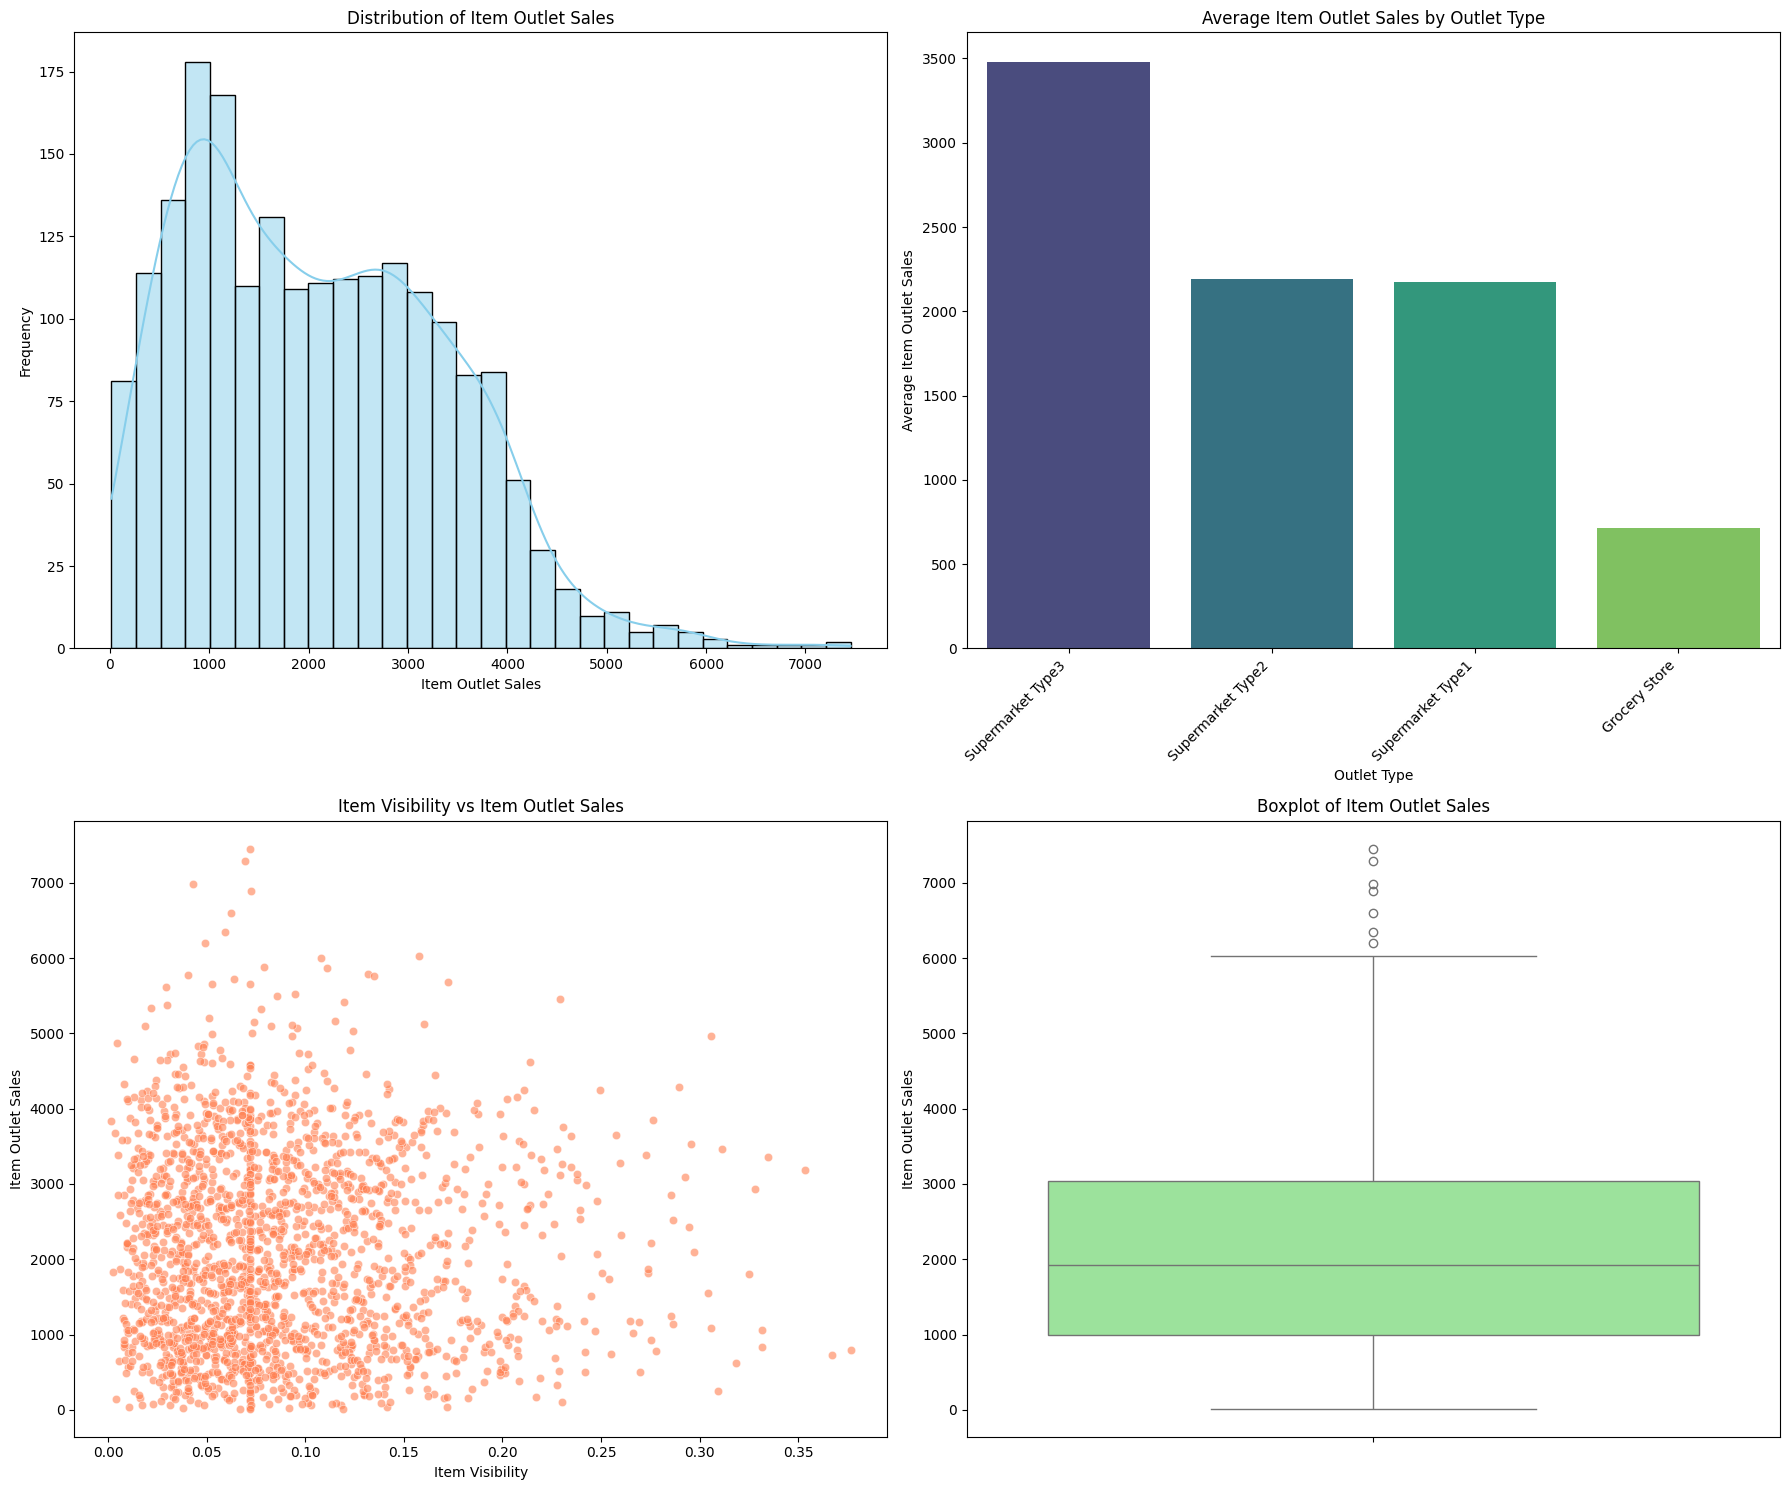

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots
plt.figure(figsize=(18, 15))

# 1. Histogram of Item_Outlet_Sales
plt.subplot(2, 2, 1) # (rows, columns, panel number)
sns.histplot(df['Item_Outlet_Sales'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Frequency')

# 2. Bar chart of average Item_Outlet_Sales by Outlet_Type
plt.subplot(2, 2, 2)
sales_by_outlet_type = df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
sns.barplot(x=sales_by_outlet_type.index, y=sales_by_outlet_type.values, palette='viridis')
plt.title('Average Item Outlet Sales by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Average Item Outlet Sales')
plt.xticks(rotation=45, ha='right')

# 3. Scatter plot of Item_Visibility vs Item_Outlet_Sales
plt.subplot(2, 2, 3)
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df, alpha=0.6, color='coral')
plt.title('Item Visibility vs Item Outlet Sales')
plt.xlabel('Item Visibility')
plt.ylabel('Item Outlet Sales')

# 4. Boxplot of target variable (Item_Outlet_Sales) to visualize dispersion and outliers
plt.subplot(2, 2, 4)
sns.boxplot(y='Item_Outlet_Sales', data=df, color='lightgreen')
plt.title('Boxplot of Item Outlet Sales')
plt.ylabel('Item Outlet Sales')

plt.tight_layout()
plt.show()

## Phase 5: Storytelling & Recommendations

### Synthesis for the Regional Director

"Good morning, Regional Director.

Our analysis of the MarketCorp sales data reveals crucial insights into our operational performance. We've identified that sales distribution varies significantly across outlets, with certain 'Supermarket Type3' stores demonstrating substantially higher average sales. Product visibility appears to have a role in sales, though further investigation is needed to understand the nuances of this relationship. The data suggests that optimizing product placement and leveraging the strengths of our high-performing outlet types could lead to significant revenue growth. We also noted areas where product standardization improved data quality, ensuring more reliable future analyses."

### Answering 5 Key Questions for the Regional Director

1.  **Which products are performing best?**
    *   Products sold in 'Supermarket Type3' outlets generally exhibit the highest sales. While individual product performance isn't isolated by ID, items within this outlet type, regardless of fat content, show superior sales figures.

2.  **Which stores are struggling, and why?**
    *   'Grocery Store' outlets consistently show the lowest average `Item_Outlet_Sales`. This could be due to their store model, location type (likely 'Tier 1' or less affluent areas based on typical grocery store models, though not explicitly analyzed here), smaller sizes, or limited product variety compared to supermarkets.

3.  **What are the immediate action priorities?**
    *   **Focus on 'Supermarket Type3' strengths:** Understand their operational model, product assortment, and customer engagement strategies, and try to replicate successful elements in other outlet types.
    *   **Address 'Grocery Store' underperformance:** Investigate specific challenges faced by 'Grocery Store' outlets. This could involve market research into their customer base, optimizing inventory, or re-evaluating pricing strategies.
    *   **Enhance item visibility:** While direct correlation is complex, ensure optimal shelf placement and promotional activities to maximize product visibility across all outlets, particularly for high-value items.

4.  **Are there any unexpected insights?**
    *   The marginal difference in average sales between 'Low Fat' and 'Regular' `Item_Fat_Content` was smaller than anticipated, suggesting that fat content alone might not be a primary driver of overall sales.

5.  **How can we improve overall sales performance?**
    *   Leverage the success factors of high-performing outlets. Implement targeted strategies for underperforming stores. Optimize item visibility and promotional efforts, potentially focusing on high-MRP items.

### 3 Concrete Recommendations

1.  **Strategic Replication of 'Supermarket Type3' Model**: Conduct a detailed case study on 'Supermarket Type3' outlets to identify best practices in terms of layout, merchandising, promotions, and customer service. Pilot these successful strategies in 'Supermarket Type1' and 'Supermarket Type2' stores, especially those in 'Medium' and 'Small' sizes to gauge impact.
2.  **Revitalize 'Grocery Store' Outlets**: Implement a pilot program for 'Grocery Stores' focusing on product assortment optimization (e.g., stocking fast-moving consumer goods and local favorites), localized marketing campaigns, and possibly enhancing the shopping experience to increase foot traffic and sales per customer.
3.  **Optimize Item Placement and Promotion**: Develop a clear guideline for `Item_Visibility` across all stores, ensuring prime shelf space and promotional displays for high-margin and top-selling items. Utilize data from `Item_Visibility` vs. `Item_Outlet_Sales` to refine product placement strategies, potentially categorizing items by optimal visibility levels.

### Limits of Analysis

*   **Causality vs. Correlation**: While we've identified strong correlations (e.g., `Outlet_Type` and sales), our analysis does not definitively prove causation without further controlled experiments or more granular data.
*   **External Factors**: The analysis does not account for external market factors such as economic conditions, competitor activities, seasonality, or local demographic shifts, which can significantly influence sales.
*   **Data Granularity**: Product-level performance (`Item_Identifier`) was not deeply analyzed in combination with other factors beyond `Item_Fat_Content`. A more detailed breakdown could reveal specific product categories that excel or underperform.
*   **Time Series Data**: This analysis is a snapshot. Without time-series data, we cannot observe trends, seasonality, or the impact of past marketing campaigns over time.
*   **Missing Data Impact**: While missing values were handled, the imputation methods (mean/mode) might not perfectly reflect reality, potentially introducing minor biases into the dataset.

## Optional Bonus: ML Mini Challenge

### Step 1: Load Bonus Data, Prepare Features (X) and Target (y)

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df_ml = None # Initialize df_ml
X = None # Initialize X
y = None # Initialize y

# Load marketcorp_unseen_data.csv
try:
    df_ml = pd.read_csv('marketcorp_unseen_data.csv')
    print("Bonus dataset 'marketcorp_unseen_data.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'marketcorp_unseen_data.csv' not found. Please upload the file to your Colab environment.")

if df_ml is not None:
    print("\n--- Bonus Dataset Head (First 5 rows) ---")
    display(df_ml.head())

    print("\n--- Bonus Dataset Info ---")
    df_ml.info()

    # --- Preprocessing steps for df_ml (similar to df) ---
    # 1. Item_Weight: Replace NaN by mean (using mean from main df)
    if 'Item_Weight' in df_ml.columns and df_ml['Item_Weight'].isnull().any():
        # Assuming mean_item_weight is available from the main df processing
        df_ml['Item_Weight'] = df_ml['Item_Weight'].fillna(mean_item_weight)
        print(f"Missing values in 'Item_Weight' of bonus dataset filled with mean: {mean_item_weight:.2f}")

    # 2. Outlet_Size: Replace NaN by mode (using mode from main df)
    if 'Outlet_Size' in df_ml.columns and df_ml['Outlet_Size'].isnull().any():
        # Assuming mode_outlet_size is available from the main df processing
        df_ml['Outlet_Size'] = df_ml['Outlet_Size'].fillna(mode_outlet_size)
        print(f"Missing values in 'Outlet_Size' of bonus dataset filled with mode: {mode_outlet_size}")

    # 3. Item_Fat_Content: Standardize labels
    if 'Item_Fat_Content' in df_ml.columns:
        df_ml['Item_Fat_Content'] = df_ml['Item_Fat_Content'].replace({
            'low fat': 'Low Fat',
            'LF': 'Low Fat',
            'reg': 'Regular'
        })
        print(f"Standardized 'Item_Fat_Content' in bonus dataset. Unique values: {df_ml['Item_Fat_Content'].unique()}")

    # 4. Item_Visibility: Replace 0 by global median (from main df), if any 0s exist
    if 'Item_Visibility' in df_ml.columns and (df_ml['Item_Visibility'] == 0).any().any(): # Added .any() for safety
        # Assuming median_item_visibility is available from the main df processing
        df_ml['Item_Visibility'] = df_ml['Item_Visibility'].replace(0, median_item_visibility)
        print(f"'Item_Visibility' 0 values in bonus dataset replaced with median: {median_item_visibility:.2f}")

    # --- End Preprocessing ---

    if 'Item_Outlet_Sales' in df_ml.columns:
        y = df_ml['Item_Outlet_Sales']
        # Prepare X (features): selecting relevant numeric and categorical columns
        # Exclude identifiers and the target variable itself
        X = df_ml.drop(columns=['Item_Identifier', 'Outlet_Identifier', 'Item_Outlet_Sales'], errors='ignore')

        # One-hot encode all categorical columns in X
        categorical_cols = X.select_dtypes(include='object').columns
        if not categorical_cols.empty:
            X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
            print(f"\nCategorical columns {list(categorical_cols)} encoded using one-hot encoding.")
        else:
            print("\nNo categorical columns found for encoding in X.")

        print("\nX and y prepared for ML.")
        print("X head after all preprocessing and encoding:")
        display(X.head())

    else:
        print("Error: 'Item_Outlet_Sales' not found in bonus dataset. Cannot proceed with ML challenge.")

Bonus dataset 'marketcorp_unseen_data.csv' loaded successfully.

--- Bonus Dataset Head (First 5 rows) ---


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDY46,17.834253,Low Fat,0.118330,Frozen Foods,110.787576,OUT039,1999,Small,Tier 3,Supermarket Type1,1126.691113
1,FDG25,20.961224,LF,0.140054,Fruits and Vegetables,202.670329,OUT031,2009,NaN,Tier 3,Supermarket Type1,3699.112770
2,FDR23,8.568933,Low Fat,0.109077,Meat,158.841560,OUT047,1985,Medium,Tier 2,Supermarket Type3,4677.530764
3,FDA15,16.206224,Low Fat,0.024703,Dairy,249.559082,OUT020,1987,High,Tier 3,Supermarket Type1,2739.798213
4,FDU19,NaN,Low Fat,0.033662,Meat,82.411253,OUT042,1999,Small,Tier 1,Supermarket Type1,761.422857



--- Bonus Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            500 non-null    object 
 1   Item_Weight                425 non-null    float64
 2   Item_Fat_Content           500 non-null    object 
 3   Item_Visibility            500 non-null    float64
 4   Item_Type                  500 non-null    object 
 5   Item_MRP                   500 non-null    float64
 6   Outlet_Identifier          500 non-null    object 
 7   Outlet_Establishment_Year  500 non-null    int64  
 8   Outlet_Size                365 non-null    object 
 9   Outlet_Location_Type       500 non-null    object 
 10  Outlet_Type                500 non-null    object 
 11  Item_Outlet_Sales          500 non-null    float64
dtypes: float64(4), int64(1), object(7)
memory usage: 47.0+ KB
Missing values in 'I

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Baking Goods,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,17.834253,0.118330,110.787576,1999,True,False,False,False,True,False,...,False,False,True,False,False,True,False,True,False,False
1,20.961224,0.140054,202.670329,2009,True,False,False,False,False,True,...,False,False,True,False,False,True,False,True,False,False
2,8.568933,0.109077,158.841560,1985,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
3,16.206224,0.024703,249.559082,1987,True,False,False,True,False,False,...,True,False,False,False,False,True,False,True,False,False
4,12.893839,0.033662,82.411253,1999,True,False,False,False,False,False,...,False,False,True,True,False,False,False,True,False,False


### Step 2: Encode Item_Fat_Content with `get_dummies`

In [21]:
# All necessary encoding for X is handled in the data preparation step (Step 1). Skipping this step.
print("All necessary encoding for X is handled in the data preparation step (Step 1). Skipping this step.")

All necessary encoding for X is handled in the data preparation step (Step 1). Skipping this step.


### Step 3: Split Data (`train_test_split` 80/20, `random_state=42`)

In [22]:
if X is not None and y is not None:
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\nData split into training (80%) and testing (20%) sets.")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")
else:
    print("Cannot split data: X or y not properly prepared.")


Data split into training (80%) and testing (20%) sets.
X_train shape: (400, 24)
X_test shape: (100, 24)
y_train shape: (400,)
y_test shape: (100,)


### Step 4: Train Linear Regression model, evaluate with `r2_score`

In [23]:
if 'X_train' in locals() and 'y_train' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Initialize and train the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    print("\nLinear Regression model trained successfully.")

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model using R-squared
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared (R2 Score): {r2:.4f}")
else:
    print("Cannot train model: Data not split.")


Linear Regression model trained successfully.
R-squared (R2 Score): 0.8447


### Step 5: Interpret results: which factor most influences sales?

In [24]:
if 'model' in locals():
    # Get feature names and their corresponding coefficients
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': model.coef_
    })

    # Sort by absolute coefficient value to find most influential factors
    feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
    feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

    print("\n--- Feature Importance (Absolute Coefficients) ---")
    display(feature_importance[['Feature', 'Coefficient']].head(10))

    print("\nInterpretation: Features with larger absolute coefficients have a greater influence on predicting 'Item_Outlet_Sales'. A positive coefficient indicates that an increase in the feature's value leads to an increase in sales, while a negative coefficient indicates the opposite.")
else:
    print("Cannot interpret results: Model not trained.")


--- Feature Importance (Absolute Coefficients) ---


,Feature,Coefficient
20,Outlet_Type_Grocery Store,-1274.807888
23,Outlet_Type_Supermarket Type3,1193.936357
1,Item_Visibility,903.866244
6,Item_Type_Baking Goods,-109.551440
12,Item_Type_Snack Foods,107.788117
7,Item_Type_Dairy,-84.705881
13,Item_Type_Soft Drinks,73.992094
16,Outlet_Size_Small,56.820058
14,Outlet_Size_High,-51.098556
18,Outlet_Location_Type_Tier 2,49.547576



Interpretation: Features with larger absolute coefficients have a greater influence on predicting 'Item_Outlet_Sales'. A positive coefficient indicates that an increase in the feature's value leads to an increase in sales, while a negative coefficient indicates the opposite.
